In [1]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *


In [4]:
# Run scan_L_A.py to generate the results for Fig2.ipynb
import pandas as pd

# Create an empty DataFrame with the specified headers
df = pd.DataFrame(columns=['L', 'A', 'NC1', 'margins', 'order'])

import glob

result_files = glob.glob('../results/sweep_L_A/*')

for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    L = data_dict['C'].L
    A = data_dict['C'].max_move
    NC1 = calc_NC1_from_data_dict(data_dict)
    margins = multiclass_functional_margin_from_data_dict(data_dict)
    order = get_order(data_dict)

    df = pd.concat([df, pd.DataFrame([{
        'L': L,
        'A': A,
        'NC1': NC1,
        'margins': margins,
        'order': order
    }])], ignore_index=True)



  0%|          | 0/65 [00:00<?, ?it/s]C:\Users\avivra\AppData\Local\Temp\ipykernel_28132\3218450527.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{
 66%|██████▌   | 43/65 [00:11<00:06,  3.60it/s]


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [10]:
accuracy_l = []

df = pd.DataFrame(columns=['L', 'A', 'accuracy', 'learning_rate'])
for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    df = pd.concat([df, pd.DataFrame([{
        'L': data_dict['C'].L,
        'A': data_dict['C'].max_move,
        'accuracy': data_dict['accuracy_l'][-1],
        'learning_rate': data_dict['C'].learning_rate
    }])], ignore_index=True)


  0%|          | 0/65 [00:00<?, ?it/s]C:\Users\avivra\AppData\Local\Temp\ipykernel_28132\4098436878.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{
100%|██████████| 65/65 [00:18<00:00,  3.50it/s]


100%|██████████| 65/65 [00:19<00:00,  3.33it/s]


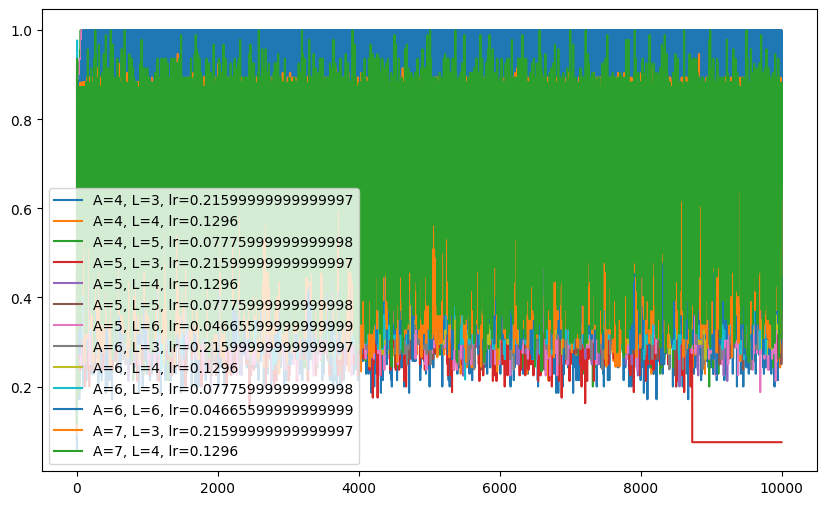

In [13]:
plt.figure(figsize=(10, 6))
for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    accuracy = data_dict['accuracy_l']
    if accuracy[-1] < 0.99:
        A = data_dict['C'].max_move
        L = data_dict['C'].L
        learning_rate = data_dict['C'].learning_rate
        plt.plot(accuracy, label=f'A={A}, L={L}, lr={learning_rate}')
plt.legend()


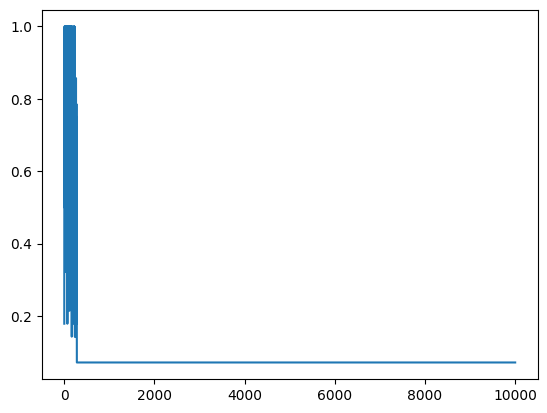

In [ ]:
data_dict = pkl.load(open('C:/Users/avivra/Desktop/cursor_projects/RepresentationShaping/results/sweep_L_A/data_max_move_1_L_7.pkl', 'rb'))
plt.plot(data_dict['accuracy_l'])

In [16]:
v2 = data_dict['C'].L
v1 = data_dict['C'].max_move
(0.6 ** ((v2+v1)/2))

0.1296